# RAGの性能評価結果の可視化

## ライブラリのインポート

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image as IPImage, display
import pandas as pd
import re

# プロジェクトパスを追加
current_dir = Path.cwd()
print(f"📁 現在のディレクトリ: {current_dir}")

# notebooks/ から プロジェクトルート へ
project_root = current_dir.parent
python_path = project_root / 'python'

print(f"📂 プロジェクトルート: {project_root}")
print(f"🐍 Pythonパス: {python_path}")

# パスを先頭に追加
sys.path.insert(0, str(python_path))

# モジュールインポート
try:
    from visualize.visualize import VisualizationGenerator
    print("✅ モジュールインポート成功")
except ImportError as e:
    print(f"❌ インポートエラー: {e}")
    print("パスを確認してください")

📁 現在のディレクトリ: /Users/shiroma/25_isco4_dev/notebooks
📂 プロジェクトルート: /Users/shiroma/25_isco4_dev
🐍 Pythonパス: /Users/shiroma/25_isco4_dev/python
✅ モジュールインポート成功


In [2]:
SUMMARY_FILE = project_root / "outputs" / "summary.xlsx"
RESULTS_DIR = project_root / "outputs" / "external" / "gemini"
PLOT_DIR = project_root / "outputs" / "plots"

## 1. データ読み込みと基本統計

In [3]:
summary_df = pd.read_excel(SUMMARY_FILE)
summary_df

,model,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness
0,gemini-2.5-flash-lite,3.398178,1.419415,0.650608,1.0,1,0.421905,0.102922,0.842608,0.900000
1,gemini-2.5-flash,10.693429,2.729780,0.642615,1.0,1,0.421905,0.195000,0.837597,0.900000
2,gemini-2.5-pro,23.452582,7.015919,0.642797,1.0,1,0.421905,0.185000,0.847541,1.000000
3,gemini-3-flash-preview,9.458730,3.992817,0.648653,1.0,1,0.421905,0.217727,0.838126,1.000000
4,gemini-3-pro-preview,21.581634,9.556782,0.552498,1.0,1,0.421905,0.116667,0.833184,0.866667


In [4]:
for file_path in RESULTS_DIR.glob("results_*.xlsx"):
    result_df = pd.read_excel(file_path)
    model_name = file_path.stem.removeprefix("results_")
    print(f"📊 {model_name}を使用したRAGの評価結果の統計:")
    print(result_df.describe())
    print()

📊 gemini-2.5-proを使用したRAGの評価結果の統計:
       llm.execution_time  rag.execution_time  llm.response_relevancy  \
count           10.000000           10.000000               10.000000   
mean            23.452582            7.015919                0.642797   
std              3.156002            1.092399                0.340511   
min             16.758634            5.682492                0.000000   
25%             22.506943            6.022722                0.751766   
50%             24.241548            6.957190                0.789576   
75%             24.841933            7.894126                0.813010   
max             28.779910            8.903380                0.872846   

       rag.context_precision  rag.context_recall  rag.context_entities_recall  \
count                   10.0                10.0                    10.000000   
mean                     1.0                 1.0                     0.421905   
std                      0.0                 0.0                 

## 2. 統計可視化

=== 可視化スクリプト ===

1. データの読み込み
   - summary.xlsx: 5件のモデル
   - results_*.xlsx: 5ファイル
     - gemini-2.5-pro: 10件
     - gemini-2.5-flash: 10件
     - gemini-3-pro-preview: 10件
     - gemini-2.5-flash-lite: 10件
     - gemini-3-flash-preview: 10件

2. グラフの生成
   - execution_time_comparison.png
   - noise_sensitivity_model_comparison.png
   - response_relevancy_comparison.png


/Users/shiroma/25_isco4_dev/python/visualize/visualize.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - faithfulness_comparison.png
   - execution_time_boxplot.png


/Users/shiroma/25_isco4_dev/python/visualize/visualize.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - noise_sensitivity_boxplot.png
   - response_relevancy_boxplot.png
   - faithfulness_boxplot.png

=== 完了: /Users/shiroma/25_isco4_dev/outputs/plots に保存しました ===

📊 生成されたプロット:


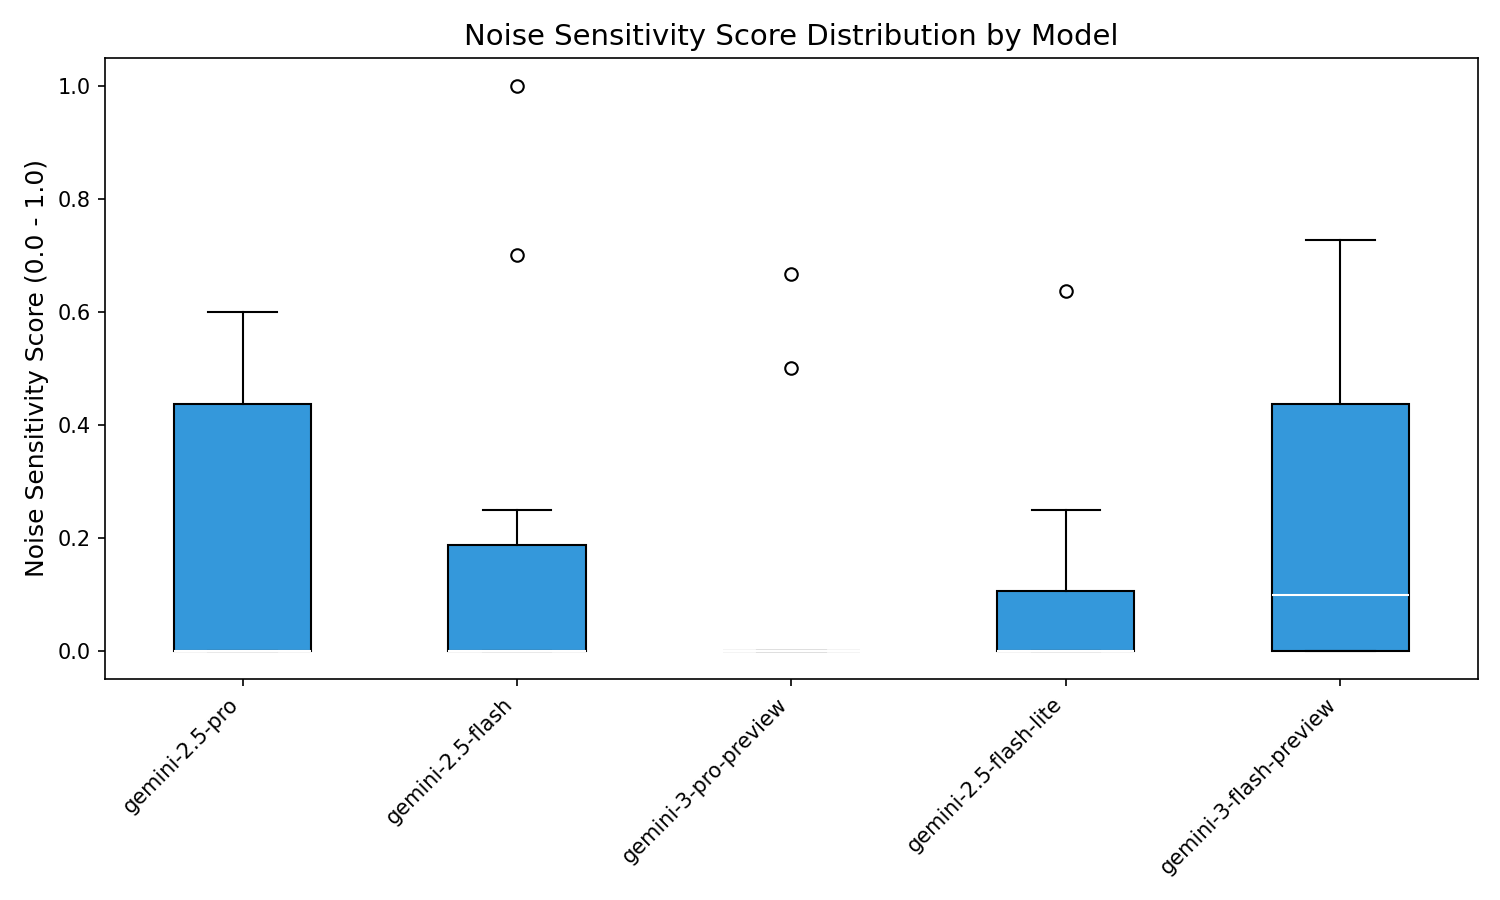

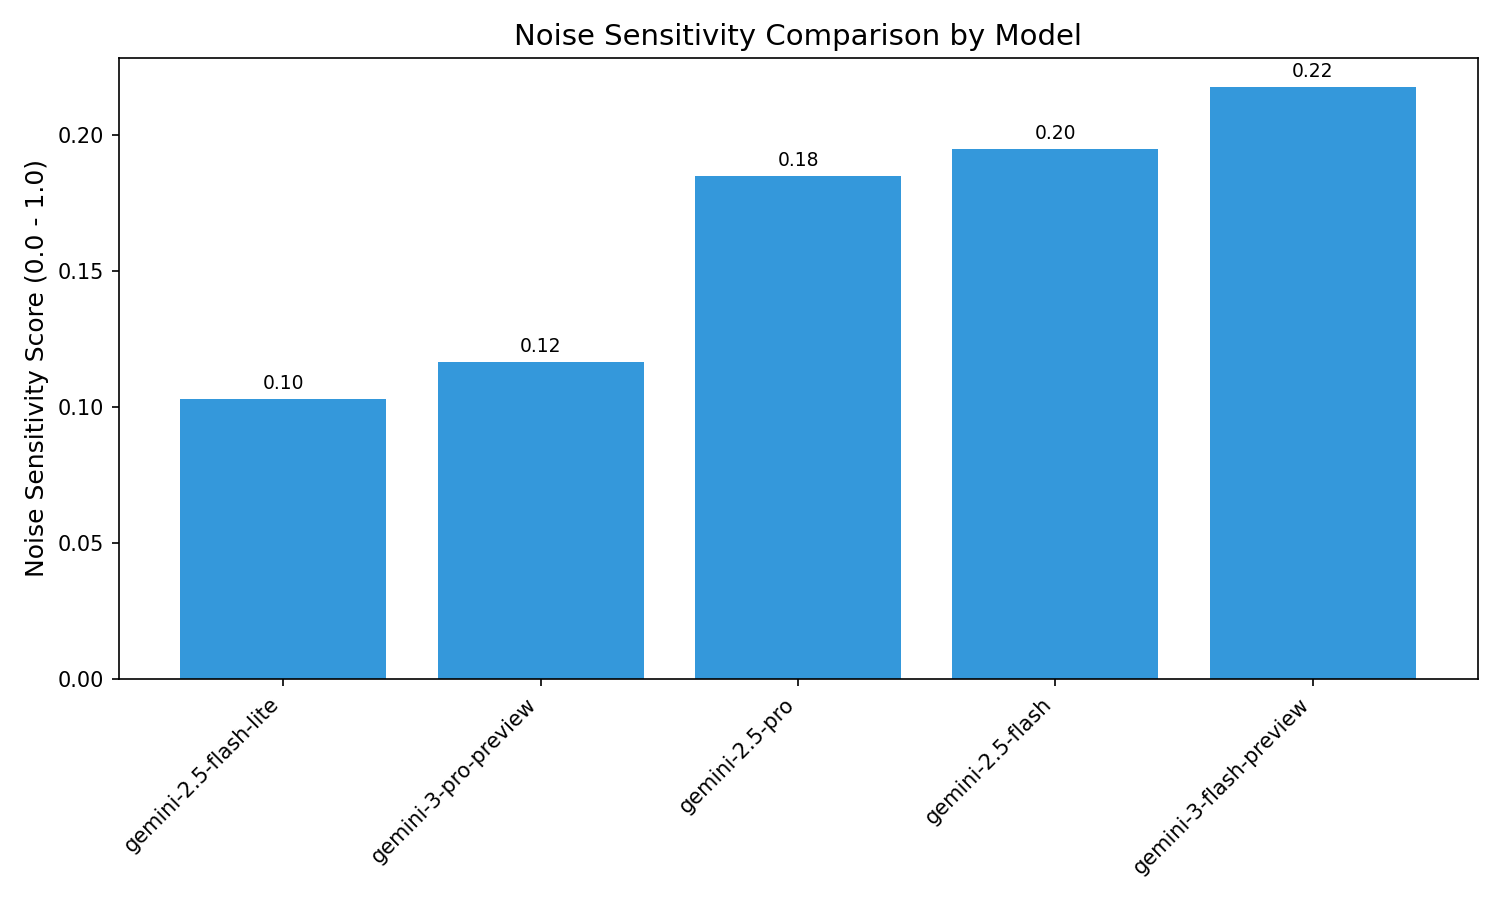

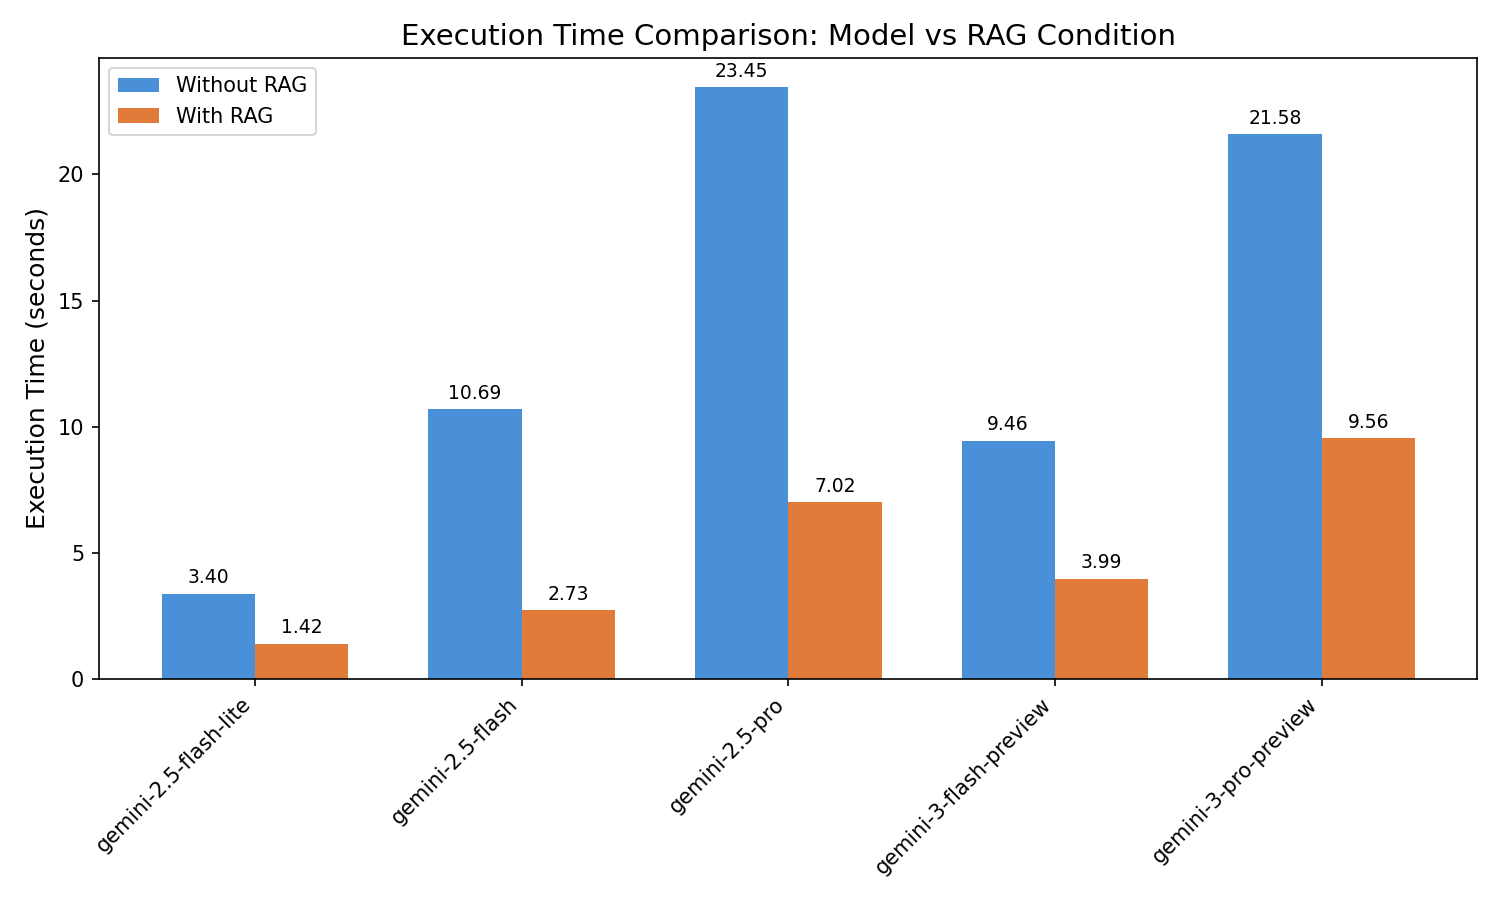

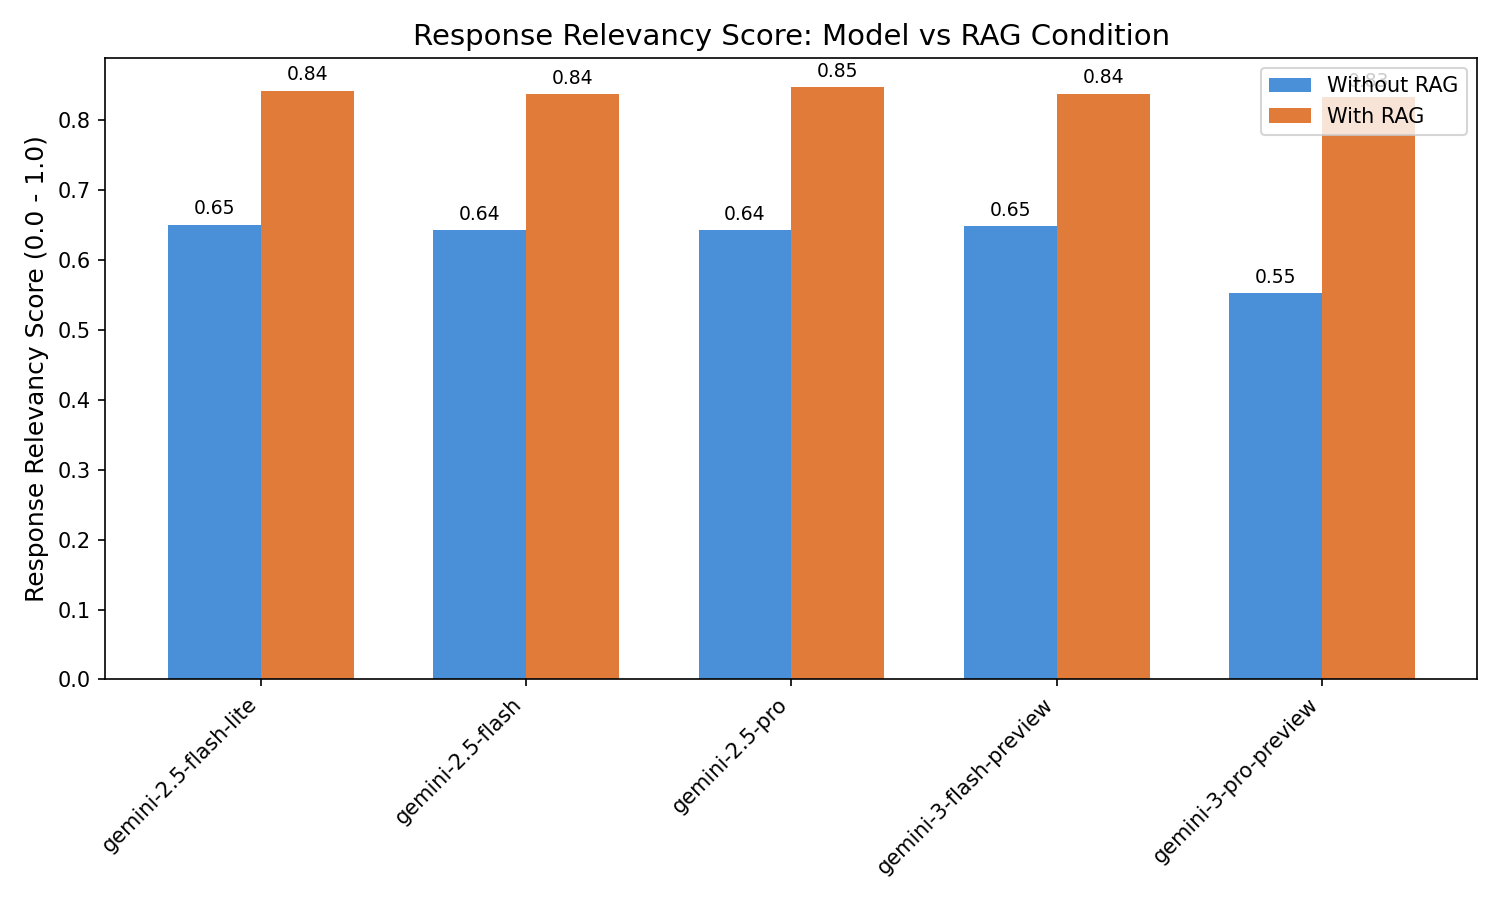

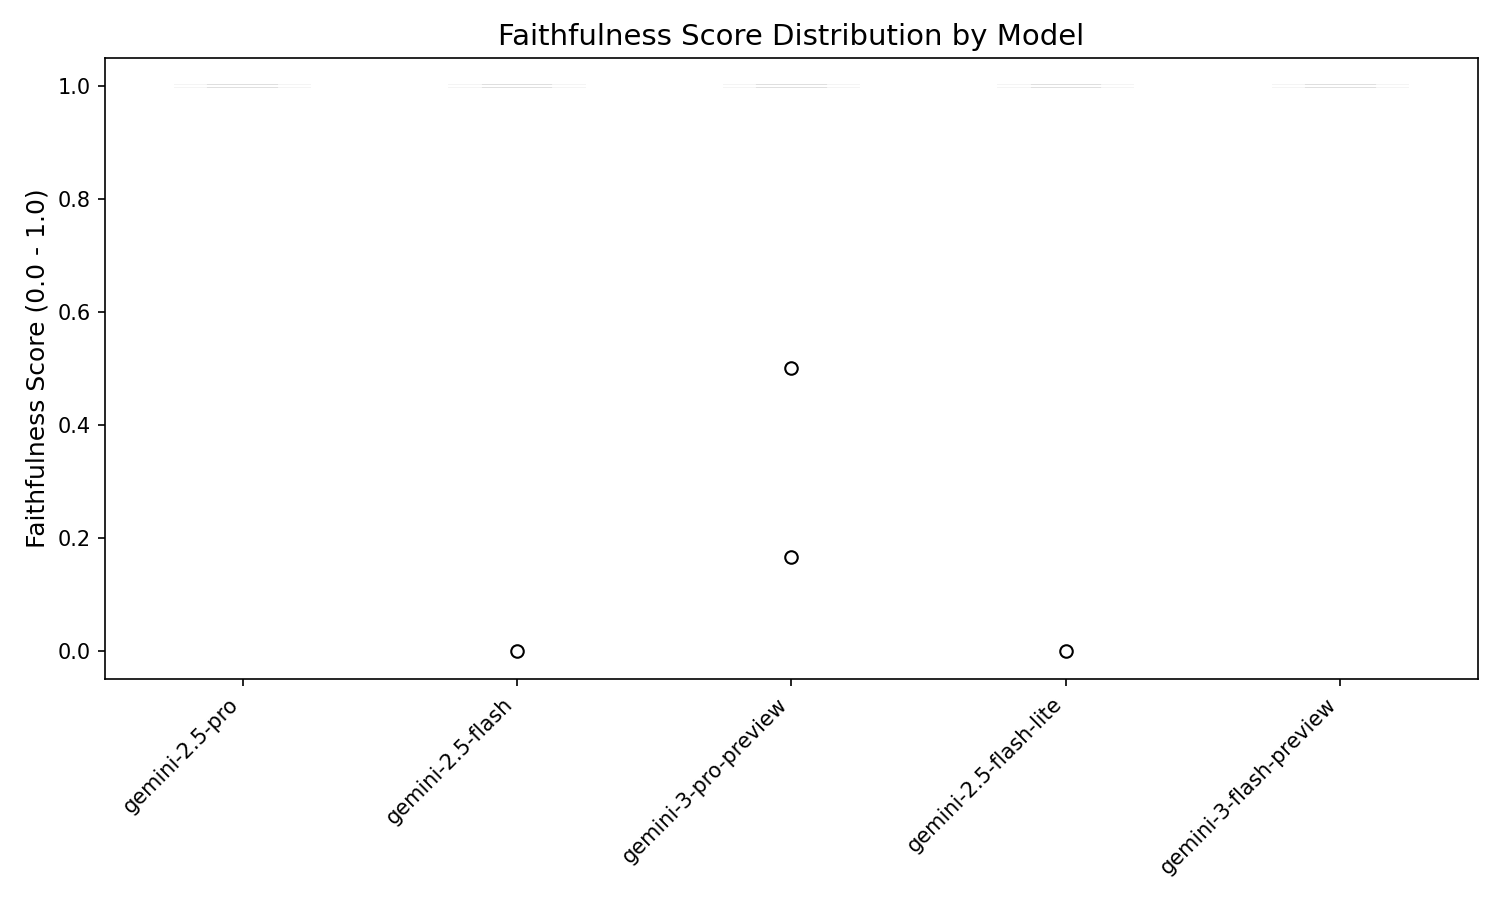

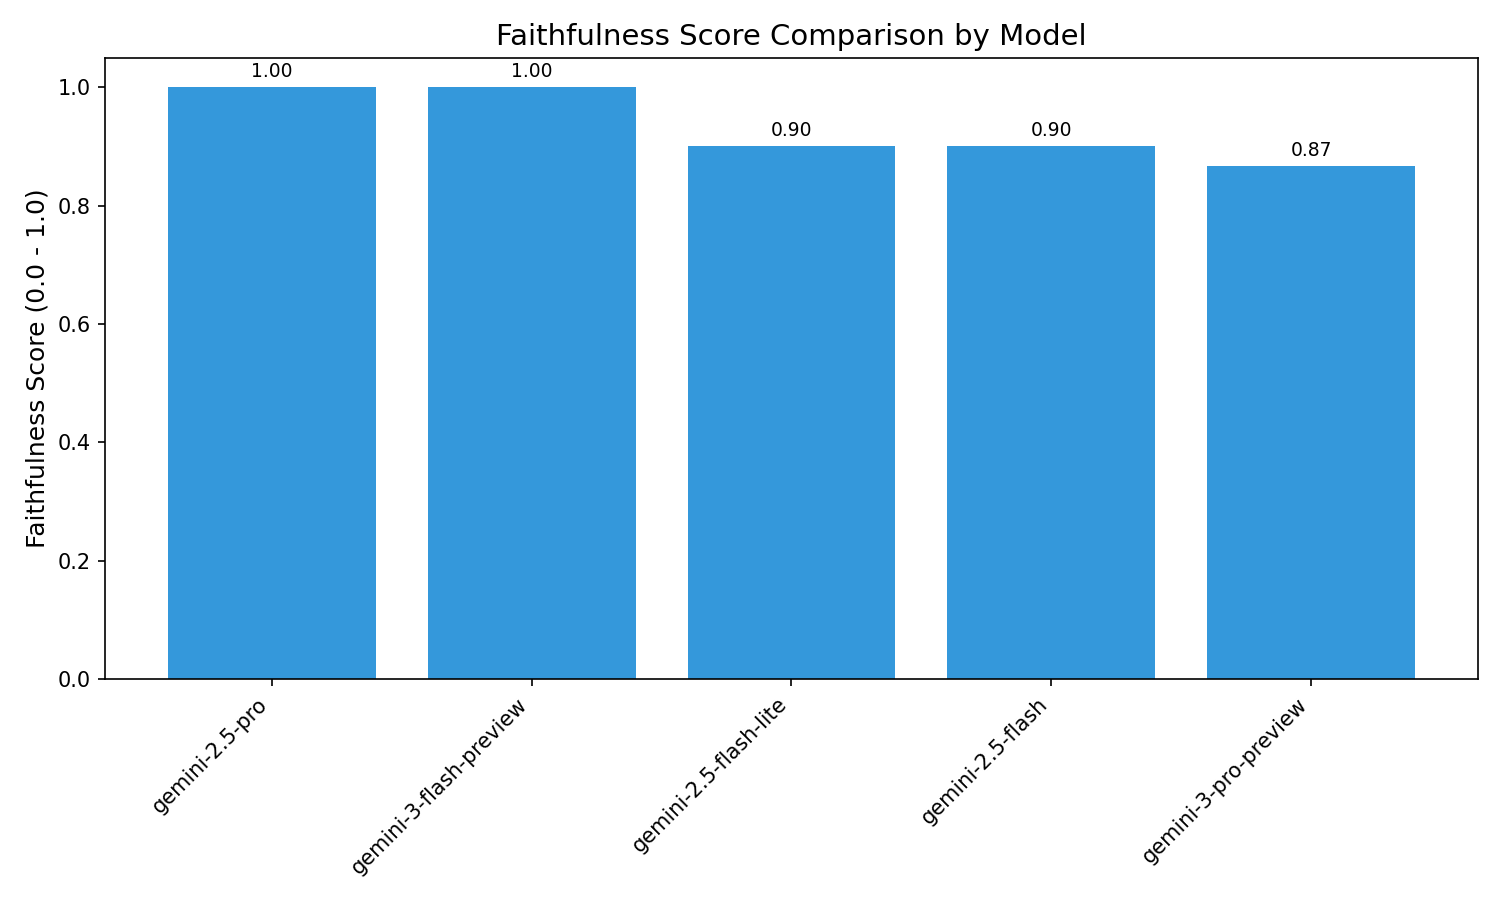

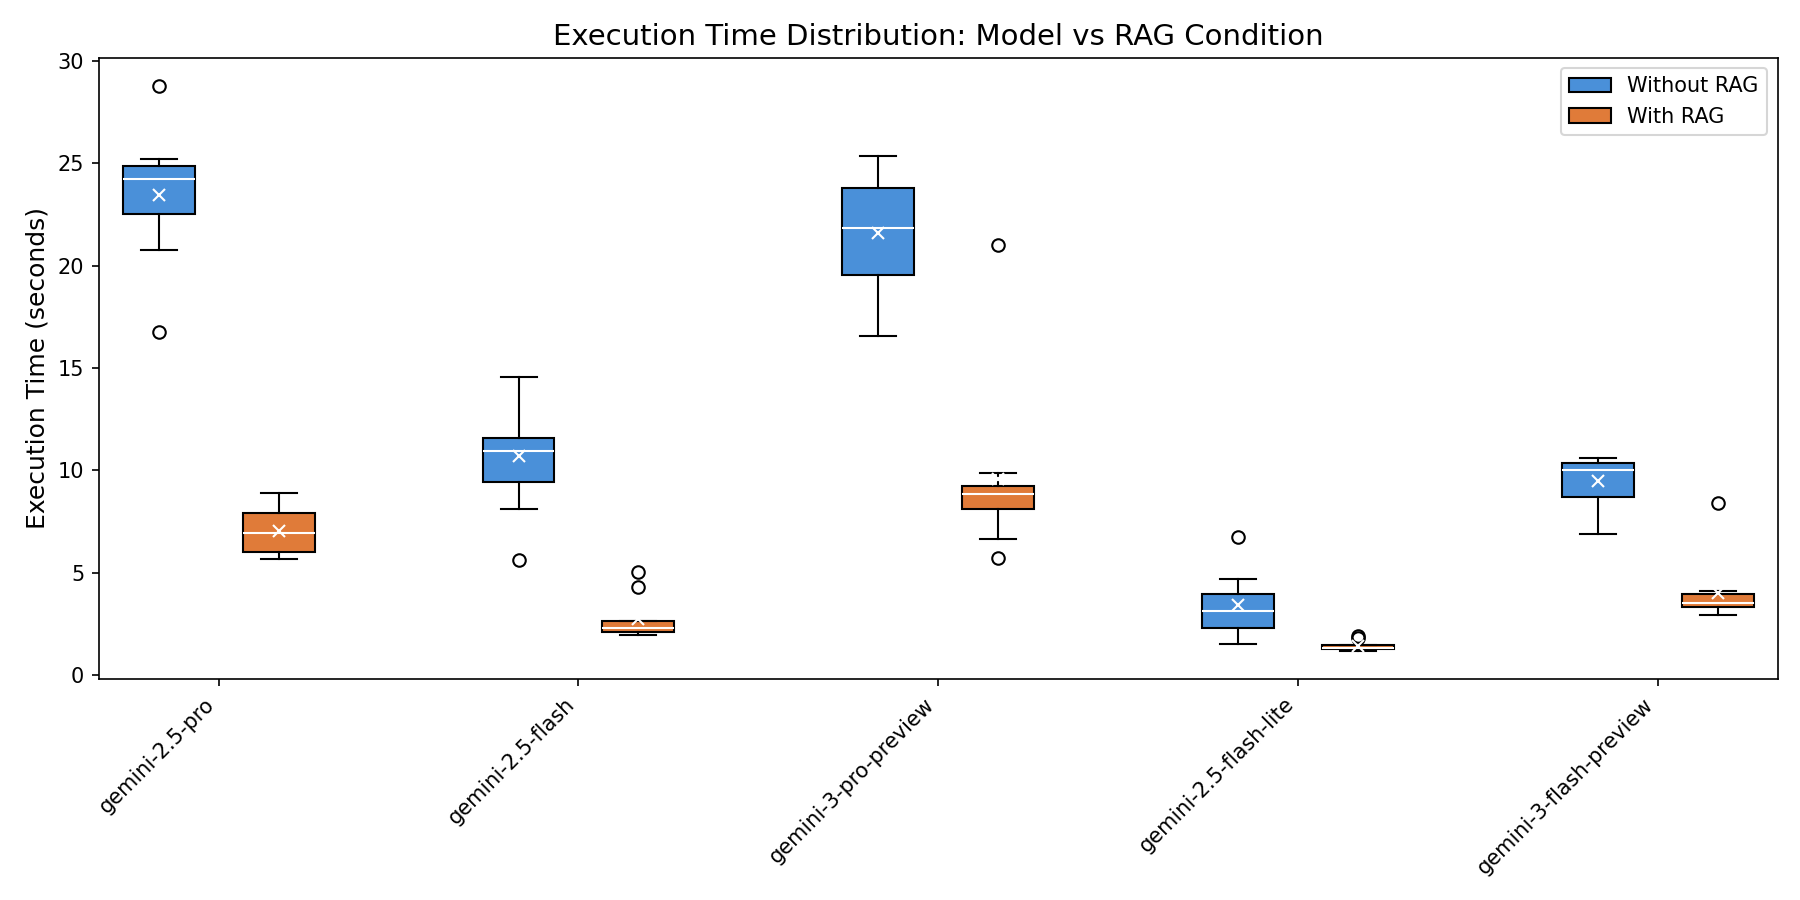

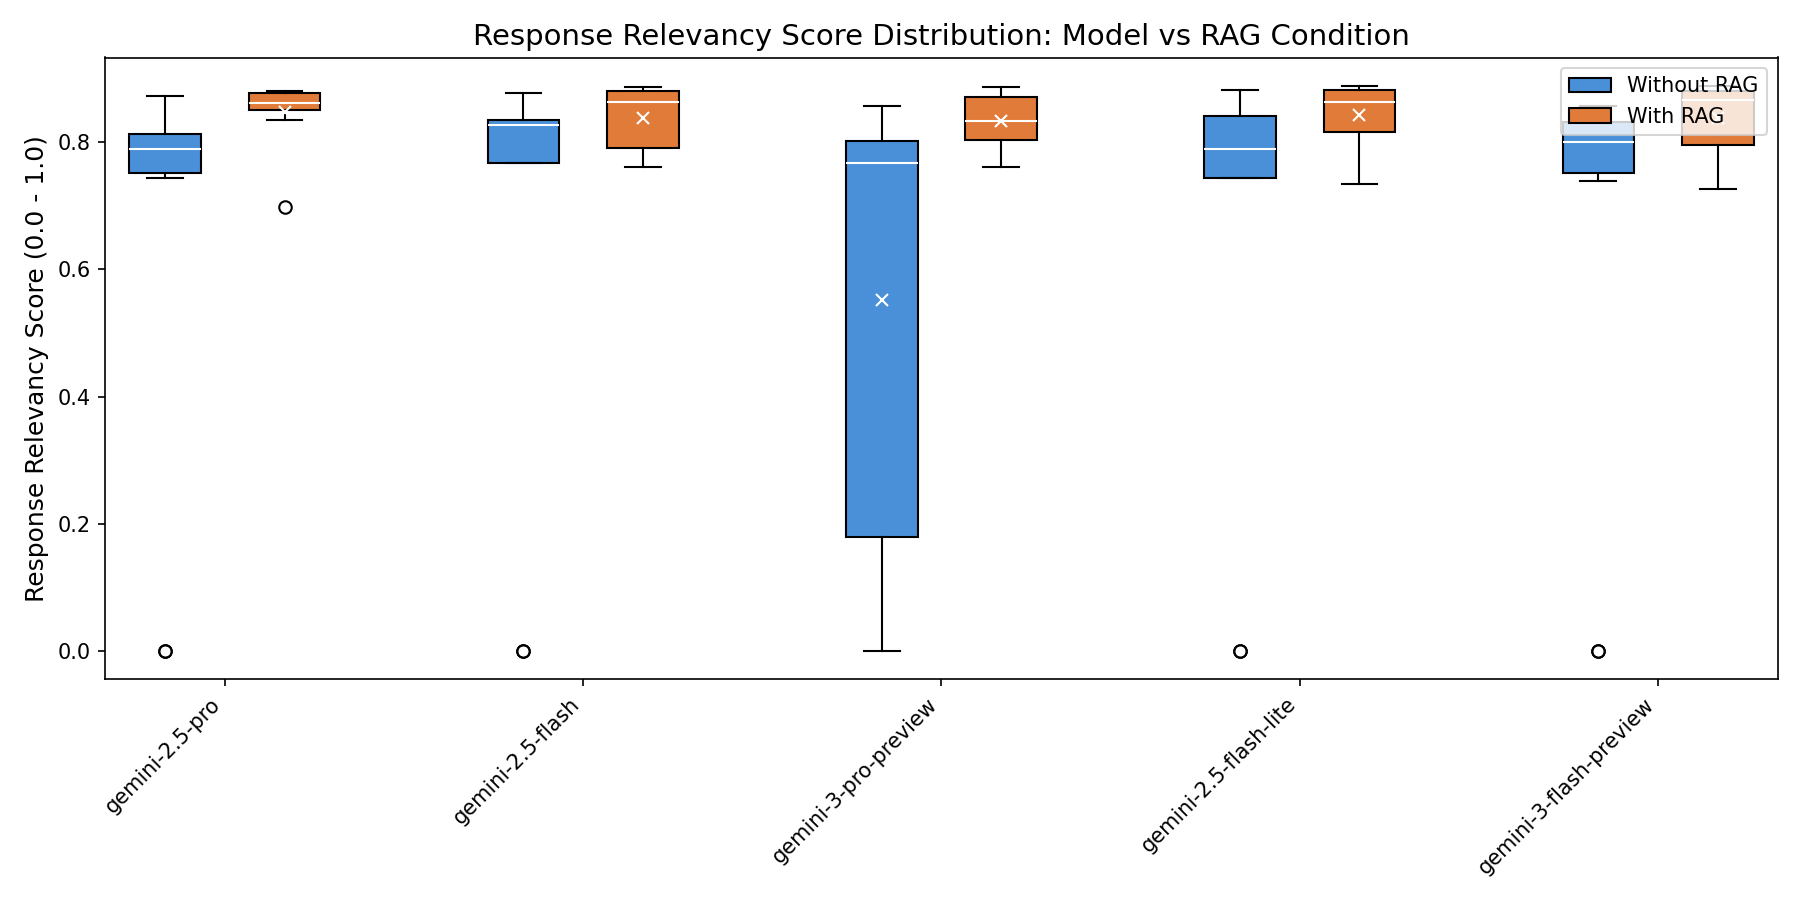

In [5]:
# 📊 統計プロット生成
generator = VisualizationGenerator()
generator.generate_all_visualizations()

# 📈 生成されたプロットを表示
print("\n📊 生成されたプロット:")
for plot_path in PLOT_DIR.glob("*.png"):
    display(IPImage(str(plot_path)))